In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [5]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [6]:
# quedarnos con el periodo para el que tenemos las variables del LLM

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [7]:
df["fecha"].describe()

count                               79
mean     2025-02-28 07:53:55.443037952
min                2025-01-02 00:00:00
25%                2025-01-29 12:00:00
50%                2025-02-26 00:00:00
75%                2025-03-29 12:00:00
max                2025-04-30 00:00:00
Name: fecha, dtype: object

In [8]:
df = df.rename(columns={
    "merval_apertura_+2": "merval",
})

In [9]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [10]:
# chequeo de cuantos NAs tenemos en cada columna
pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval_cierre,0,0.0
merval_maximo,0,0.0
emae_tendencia_ciclo_ma_5,0,0.0
badlar_ma_3,0,0.0
...,...,...
m2_diff3,0,0.0
base_monetaria_diff10,0,0.0
tasa_prestamos_personales_hp_rm20,0,0.0
prestamos_privados_ars_diff1,0,0.0


In [11]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()

In [12]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha o si la convertimos a numerica

## Train-Test Split

In [13]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(63, 60)
(16, 60)


## Funcion objetivo para Optuna y Cross-Validation

In [14]:
max_lag = 5 # por el moving average 5

In [17]:
def objective(trial):
    # Espacios de búsqueda ajustados para ~63 filas de entrenamiento y 60 features
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,

        # Aprendizaje: mayor learning rate con pocos datos para evitar sobreajuste
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.3, log=True),

        # Complejidad del árbol: REDUCIDA para evitar overfitting
        "num_leaves": trial.suggest_int("num_leaves", 5, 15),  # Mucho más simple
        "max_depth": trial.suggest_int("max_depth", 2, 4),  # Árboles poco profundos

        # Mínimos ajustados a dataset pequeño
        "min_child_samples": trial.suggest_int("min_child_samples", 3, 10),  # Menor con pocos datos

        # Regularizaciones L1/L2 - MÁS FUERTES para evitar overfitting
        "lambda_l1": trial.suggest_float("lambda_l1", 0.1, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.1, 20.0, log=True),

        # min_split_gain más alto para evitar splits innecesarios
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 2.0),

        # Submuestreo: menos agresivo con pocos datos
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),  # Feature sampling importante

        # MENOS árboles con dataset pequeño
        "n_estimators": trial.suggest_int("n_estimators", 20, 150),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes (evitan configuraciones inválidas) ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth: num_leaves <= 2**max_depth cuando max_depth>0
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1

    # --------------------------------------------------------------------------

    # Cross validation con MENOS splits para dataset pequeño
    n_splits = 3  # Solo 3 folds con 63 filas
    test_size = 8  # ~2 semanas de validación
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]  # Menos rounds
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [18]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval")
study.optimize(objective, n_trials=30, show_progress_bar=True)  # Reducido de 50 a 30 trials

print("Mejores hiperparámetros:", study.best_params)
print("Mejor RMSE CV promedio:", study.best_value)

[I 2025-11-15 11:18:52,751] A new study created in memory with name: lgbm_merval


  0%|          | 0/30 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-15 11:18:52,838] Trial 0 finished with value: 110064.2733269423 and parameters: {'learning_rate': 0.1902397018260589, 'num_leaves': 12, 'max_depth': 2, 'min_child_samples': 5, 'lambda_l1': 6.817168420937974, 'lambda_l2': 2.141815654728079, 'min_split_gain': 0.6301395643246359, 'subsample': 0.8186858764011329, 'colsample_bytree': 0.5435136638628562, 'n_estimators': 53}. Best is trial 0 with value: 110064.2733269423.
[I 2025-11-15 11:18:52,908] Trial 1 finished with value: 159296.87317810985 and parameters: {'learning_rate': 0.12234329853547478, 'num_leaves': 14, 'max_depth': 2, 'min_child_samples': 5, 'lambda_l1': 0.27710207884145266, 'lambda_l2': 18.759990107609955, 'min_split_gain': 1.79272653323925, 'subsample': 0.7800776092016679, 'colsample_bytree': 0.5727102650321074, 'n_estimators': 28}. Best is trial 0 with value: 110064.2733269423.
[I 2025-11-15 11:18:52,976] Trial 2 finished with value: 113020.14178134082 and parameters: {'learning_rate': 0.16237266605616504, 'num_l

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

...

[I 2025-11-15 11:18:55,291] Trial 24 finished with value: 114689.82833967607 and parameters: {'learning_rate': 0.1768968321367472, 'num_leaves': 11, 'max_depth': 3, 'min_child_samples': 7, 'lambda_l1': 2.526448745434784, 'lambda_l2': 0.5835624186079973, 'min_split_gain': 1.3543149107719636, 'subsample': 0.8527731478807131, 'colsample_bytree': 0.6015608783528503, 'n_estimators': 73}. Best is trial 16 with value: 102215.58930811333.
[I 2025-11-15 11:18:55,465] Trial 25 finished with value: 107157.0222977032 and parameters: {'learning_rate': 0.1385400361427243, 'num_leaves': 13, 'max_depth': 3, 'min_child_samples': 4, 'lambda_l1': 0.6163021078594608, 'lambda_l2': 0.30548670360018276, 'min_split_gain': 1.063165242172554, 'subsample': 0.9177257072237075, 'colsample_bytree': 0.6790184473467858, 'n_estimators': 66}. Best is trial 16 with value: 102215.58930811333.


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-15 11:18:55,575] Trial 26 finished with value: 102934.23378713995 and parameters: {'learning_rate': 0.2695119584052297, 'num_leaves': 10, 'max_depth': 3, 'min_child_samples': 5, 'lambda_l1': 9.958019627280837, 'lambda_l2': 0.16826171963182368, 'min_split_gain': 1.0615435408350355, 'subsample': 0.885708048289719, 'colsample_bytree': 0.7411620471234006, 'n_estimators': 35}. Best is trial 16 with value: 102215.58930811333.
[I 2025-11-15 11:18:55,699] Trial 27 finished with value: 105457.41336350965 and parameters: {'learning_rate': 0.26805893202160896, 'num_leaves': 10, 'max_depth': 4, 'min_child_samples': 6, 'lambda_l1': 9.480196360000578, 'lambda_l2': 0.1657287953930579, 'min_split_gain': 1.6871221014078617, 'subsample': 0.8996921999348022, 'colsample_bytree': 0.7330466728412119, 'n_estimators': 40}. Best is trial 16 with value: 102215.58930811333.


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-15 11:18:55,826] Trial 28 finished with value: 132883.64341496376 and parameters: {'learning_rate': 0.2932864806992665, 'num_leaves': 9, 'max_depth': 2, 'min_child_samples': 5, 'lambda_l1': 4.856601034129612, 'lambda_l2': 0.13500369649997696, 'min_split_gain': 1.071185748033703, 'subsample': 0.9681831133829992, 'colsample_bytree': 0.779133971517985, 'n_estimators': 24}. Best is trial 16 with value: 102215.58930811333.
[I 2025-11-15 11:18:55,949] Trial 29 finished with value: 97741.6357143267 and parameters: {'learning_rate': 0.22310435076576982, 'num_leaves': 9, 'max_depth': 2, 'min_child_samples': 5, 'lambda_l1': 7.189874386318636, 'lambda_l2': 0.6538503486847803, 'min_split_gain': 0.7763600136088123, 'subsample': 0.8231484533637592, 'colsample_bytree': 0.896534579240467, 'n_estimators': 50}. Best is trial 29 with value: 97741.6357143267.
Mejores hiperparámetros: {'learning_rate': 0.22310435076576982, 'num_leaves': 9, 'max_depth': 2, 'min_child_samples': 5, 'lambda_l1': 7.1

In [19]:
study.best_params

{'learning_rate': 0.22310435076576982,
 'num_leaves': 9,
 'max_depth': 2,
 'min_child_samples': 5,
 'lambda_l1': 7.189874386318636,
 'lambda_l2': 0.6538503486847803,
 'min_split_gain': 0.7763600136088123,
 'subsample': 0.8231484533637592,
 'colsample_bytree': 0.896534579240467,
 'n_estimators': 50}

In [20]:
best_params = study.best_params
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=7.189874386318636, reg_alpha=0.0 will be ignored. Current value: lambda_l1=7.189874386318636
[LightGBM] [Warning] lambda_l2 is set=0.6538503486847803, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.6538503486847803
[LightGBM] [Warning] lambda_l1 is set=7.189874386318636, reg_alpha=0.0 will be ignored. Current value: lambda_l1=7.189874386318636
[LightGBM] [Warning] lambda_l2 is set=0.6538503486847803, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.6538503486847803
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1188
[LightGBM] [Info] Number of data points in the train set: 63, number of used features: 60
[LightGBM] [Info] Start training from score 2435670.507937
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

LGBMRegressor(colsample_bytree=0.896534579240467, lambda_l1=7.189874386318636,
              lambda_l2=0.6538503486847803, learning_rate=0.22310435076576982,
              max_depth=2, min_child_samples=5,
              min_split_gain=0.7763600136088123, n_estimators=50, num_leaves=9,
              subsample=0.8231484533637592)

## Test

In [21]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


[LightGBM] [Warning] lambda_l1 is set=7.189874386318636, reg_alpha=0.0 will be ignored. Current value: lambda_l1=7.189874386318636
[LightGBM] [Warning] lambda_l2 is set=0.6538503486847803, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.6538503486847803
Holdout RMSE: 207860.8282
Holdout R²:   -4.9342


In [22]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

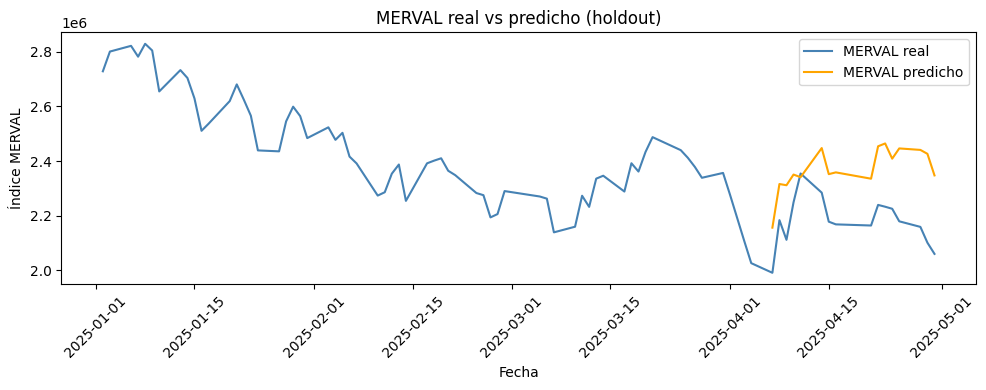

In [23]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


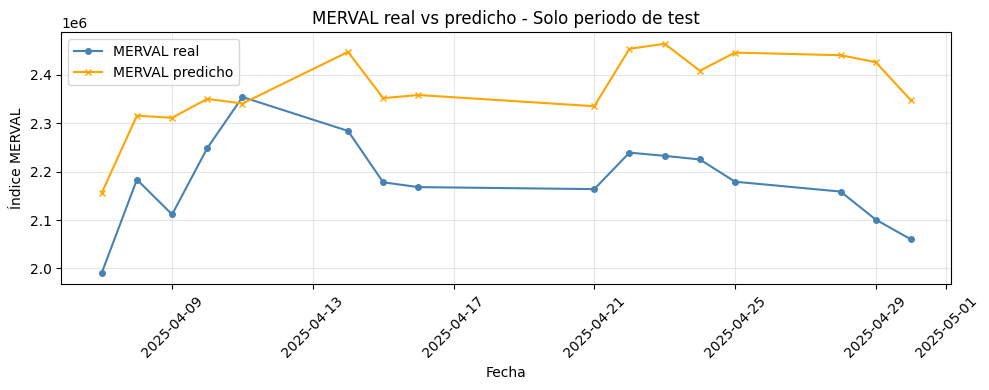

In [24]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test["fecha"], df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test["fecha"], df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

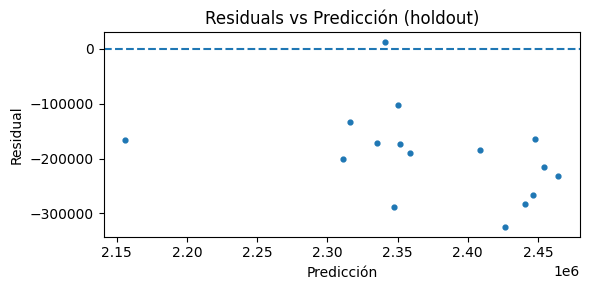

In [25]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


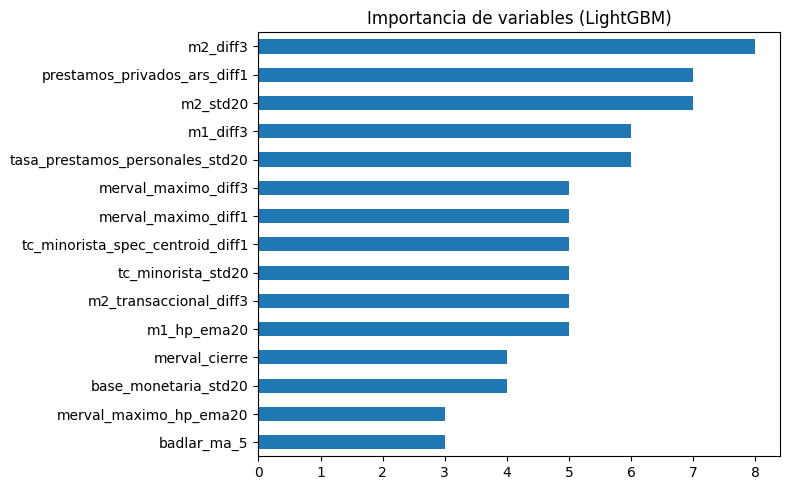

In [26]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()
